In [1]:
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import pandas as pd

from hydrax.utils.files import get_data_path, get_img_path, mkdir

#### Sample Sweeps
Currently running 12 horizon steps, 4 sim steps per control input and 0.01 simulation timestep.

In [2]:
num_samples_sweep = [128, 256, 512, 1024, 2048]
num_randomizations_sweep = [1, 2, 4, 8, 16]
trajectory_length = 199

algos = ["mppi", "cem", "mtp", "anmtp"]
alg_labels = ["MPPI", "CEM", "MTP", "AnMTP"]

horizon = 12
steps_per_control = 4

data_path = get_data_path()
img_path = get_img_path()

records = []
for i, alg in enumerate(algos):

    path = f"{data_path}/scaling/scaling_data_samples_{horizon}_{steps_per_control}/{alg}.pkl"
    with open(path, "rb") as f:
        algo_data = pickle.load(f) # samples x randomizations x steps

    for j, p1 in enumerate(num_samples_sweep):
        for k, p2 in enumerate(num_randomizations_sweep):
            for r in range(trajectory_length):

                if r > 0:
                # if algo_data[j, k, r] > 1e-15:
                        
                    records.append({
                        'Algorithm': alg_labels[i],
                        'Samples': p1,
                        'Domains': p2,
                        'Runtime': algo_data[j, k, r],
                        "Frequency": 1 / (algo_data[j, k, r]) 
                    })
                # print outliers
                if algo_data[j, k, r] < 1e-15:
                    print(f"Outlier detected: {algo_data[j, k, r]}")
                    print(f"Algorithm: {alg_labels[i]}, Samples: {p1}, Domains: {p2}, Step: {r}")

df = pd.DataFrame.from_records(records)

Outlier detected: 6.77855816682316e-310
Algorithm: MPPI, Samples: 128, Domains: 1, Step: 0
Outlier detected: 3.116381739442364e-19
Algorithm: MPPI, Samples: 128, Domains: 2, Step: 0
Outlier detected: -3.6129101675959817e-13
Algorithm: MPPI, Samples: 128, Domains: 4, Step: 0
Outlier detected: 4.3556980160050434e-16
Algorithm: MPPI, Samples: 128, Domains: 8, Step: 0
Outlier detected: -1.748703150368007e-29
Algorithm: MPPI, Samples: 128, Domains: 16, Step: 0
Outlier detected: -5.389344523636737e-13
Algorithm: MPPI, Samples: 256, Domains: 1, Step: 0
Outlier detected: -4.089636008008352e-23
Algorithm: MPPI, Samples: 256, Domains: 2, Step: 0
Outlier detected: -8.877230434109775e-26
Algorithm: MPPI, Samples: 256, Domains: 4, Step: 0
Outlier detected: -1.6438671418878833e-23
Algorithm: MPPI, Samples: 256, Domains: 8, Step: 0
Outlier detected: -1.9918181744862365e-21
Algorithm: MPPI, Samples: 256, Domains: 16, Step: 0
Outlier detected: -3.849359534794273e-24
Algorithm: MPPI, Samples: 512, Domai

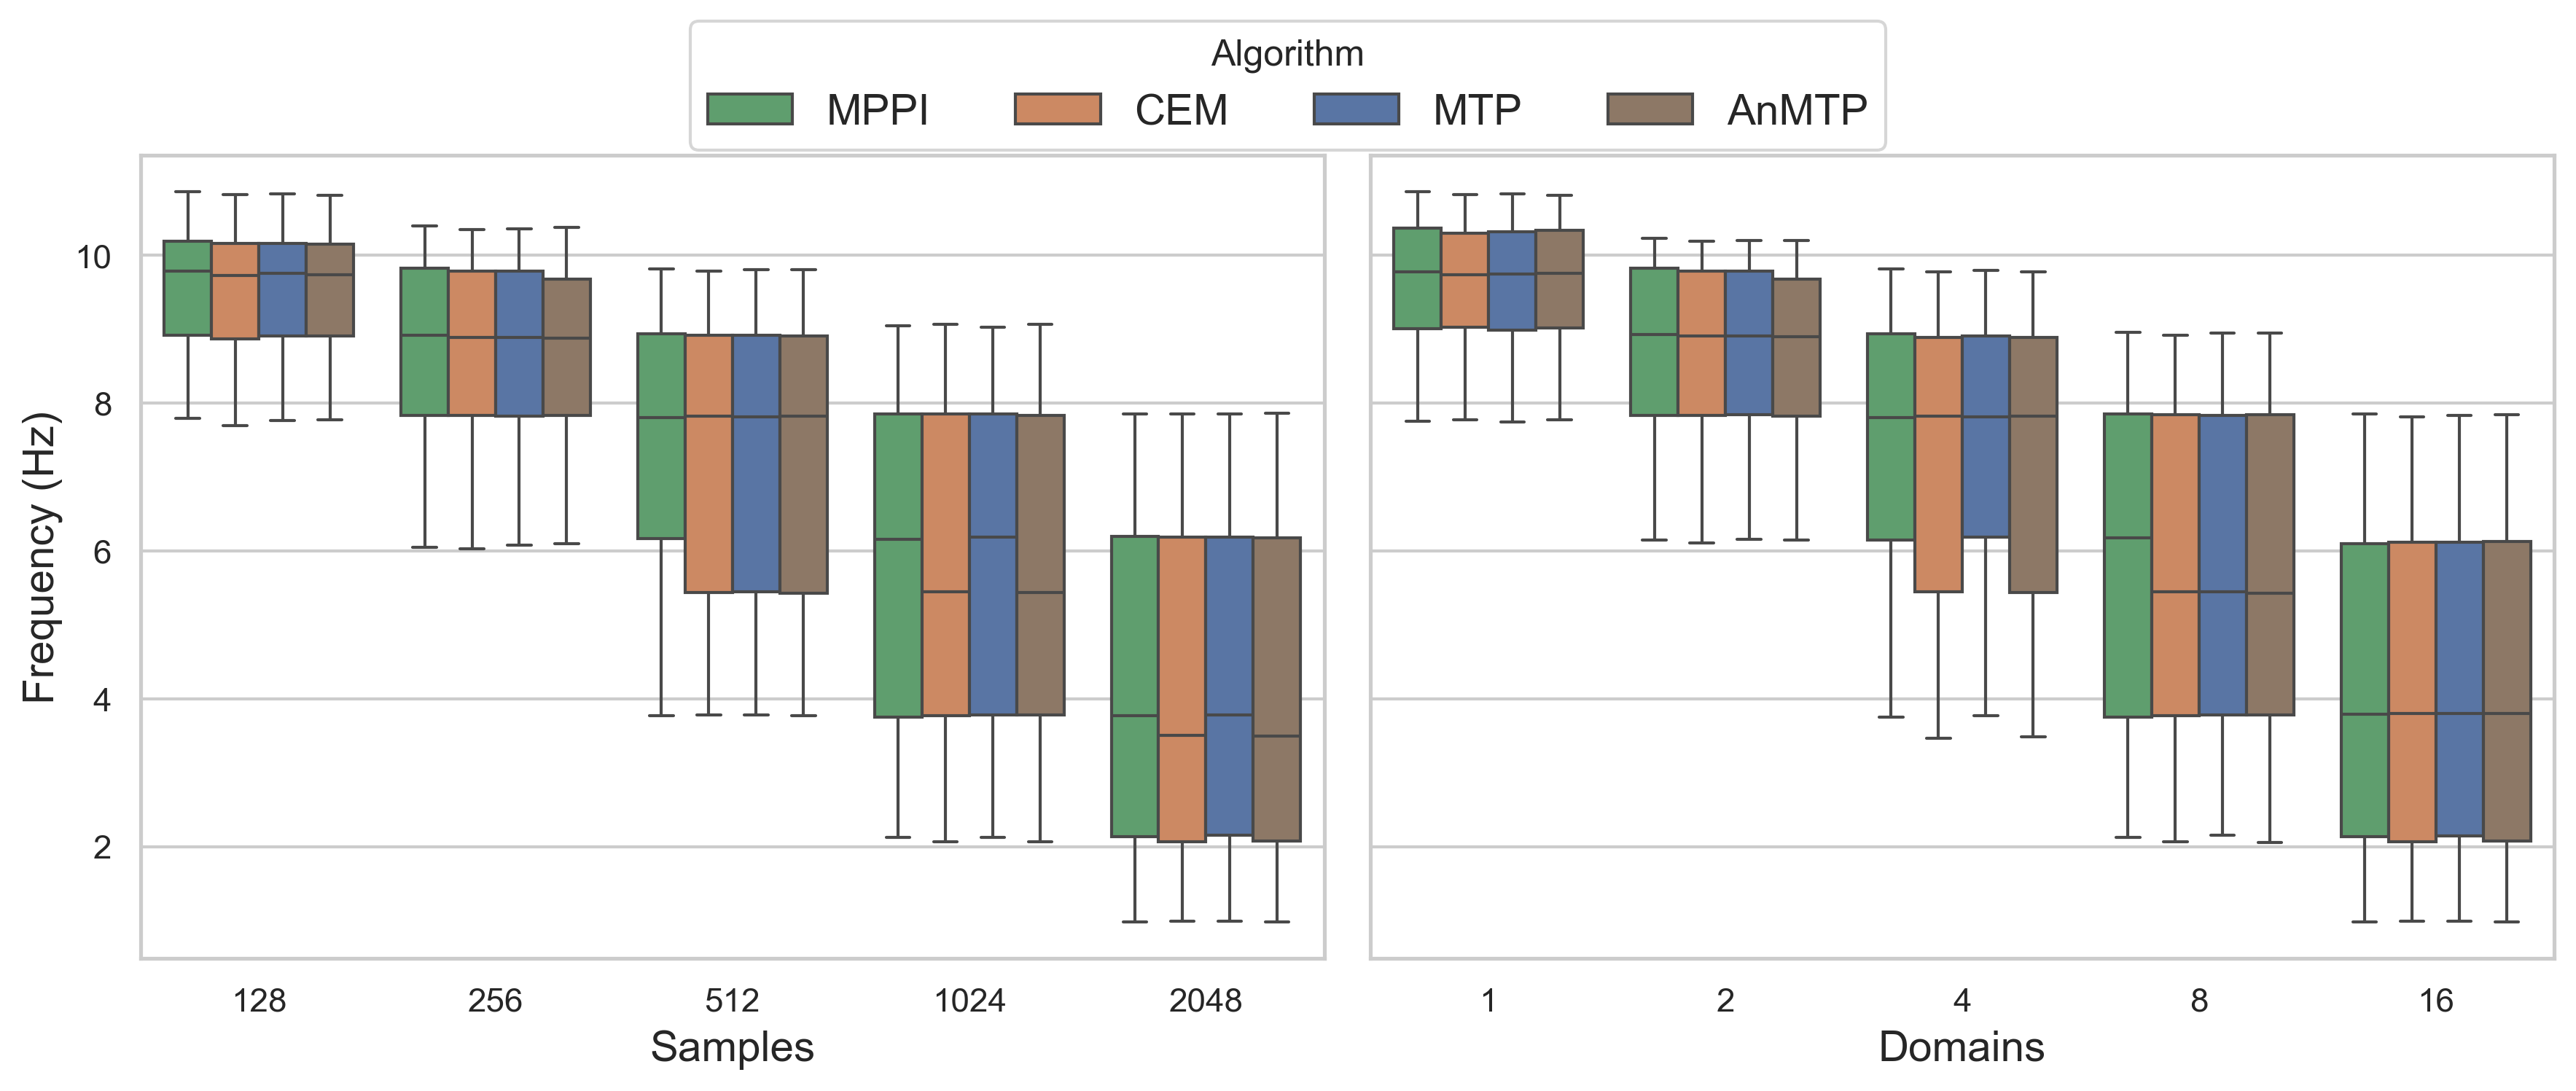

In [ ]:
sns.set_theme(style="whitegrid", rc={"figure.dpi": 300, "font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "legend.fontsize": 14})
palette = {
    "MPPI": sns.color_palette()[2],
    "CEM": sns.color_palette()[1],
    "MTP": sns.color_palette()[0],
    "AnMTP": sns.color_palette()[5],
}


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: Runtime vs Samples
sns.boxplot(data=df, x='Samples', y='Frequency', hue='Algorithm', palette=palette, ax=axes[0])
axes[0].set_xlabel('Samples')
axes[0].set_ylabel('Frequency (Hz)')

# Right: Runtime vs Domains
sns.boxplot(data=df, x='Domains', y='Frequency', hue='Algorithm', palette=palette, ax=axes[1])
axes[1].set_xlabel('Domains')
axes[1].set_ylabel('Frequency (Hz)')

# Improve legend layout
axes[0].legend_.remove()  # Remove duplicate legend
axes[1].legend_.remove()  # Remove duplicate legend

plt.subplots_adjust(top=0.95)

# ---- Fix the legend duplication ----
# Get unique handles and labels from one of the subplots
handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))  # removes duplicates while preserving order

# Add a single legend for the whole figure
fig.legend(
    unique.values(),
    unique.keys(),
    title='Algorithm',
    loc='upper center',
    ncol=len(unique),  # one row of legend items
    bbox_to_anchor=(0.5, 1.02)
)
# fig.legend(title='Algorithm', loc='upper center', ncol=1, )

plt.tight_layout(rect=[0, 0, 1, 0.92])  # prevent overlap with legend
mkdir(f"{img_path}/scaling")
plt.savefig(f"{img_path}/scaling/samples_sweep.pdf", bbox_inches="tight", dpi=300)

plt.show()

#### Horizon Sweeps
Using 128 samples over 6 domains

In [4]:
algos = ["mppi", "cem", "mtp", "anmtp"]
horizons = [4, 6, 8, 10, 12, 14]
steps_per_control = [4, 6, 8, 10, 12, 14]



records2 = []
for i, alg in enumerate(algos):

    path = f"{data_path}/scaling/scaling_data_horizon/{alg}.pkl"
    with open(path, "rb") as f:
        algo_data = pickle.load(f) # samples x randomizations x steps

    for j, p1 in enumerate(horizons):
        for k, p2 in enumerate(steps_per_control):
            for r in range(trajectory_length):

                if r > 0:
                    records2.append({
                        'Algorithm': alg_labels[i],
                        'Horizon': p1,
                        'Steps per Control': p2,
                        'Runtime': algo_data[j, k, r],
                        "Frequency": 1 / (algo_data[j, k, r]) 
                    })

df2 = pd.DataFrame.from_records(records2)

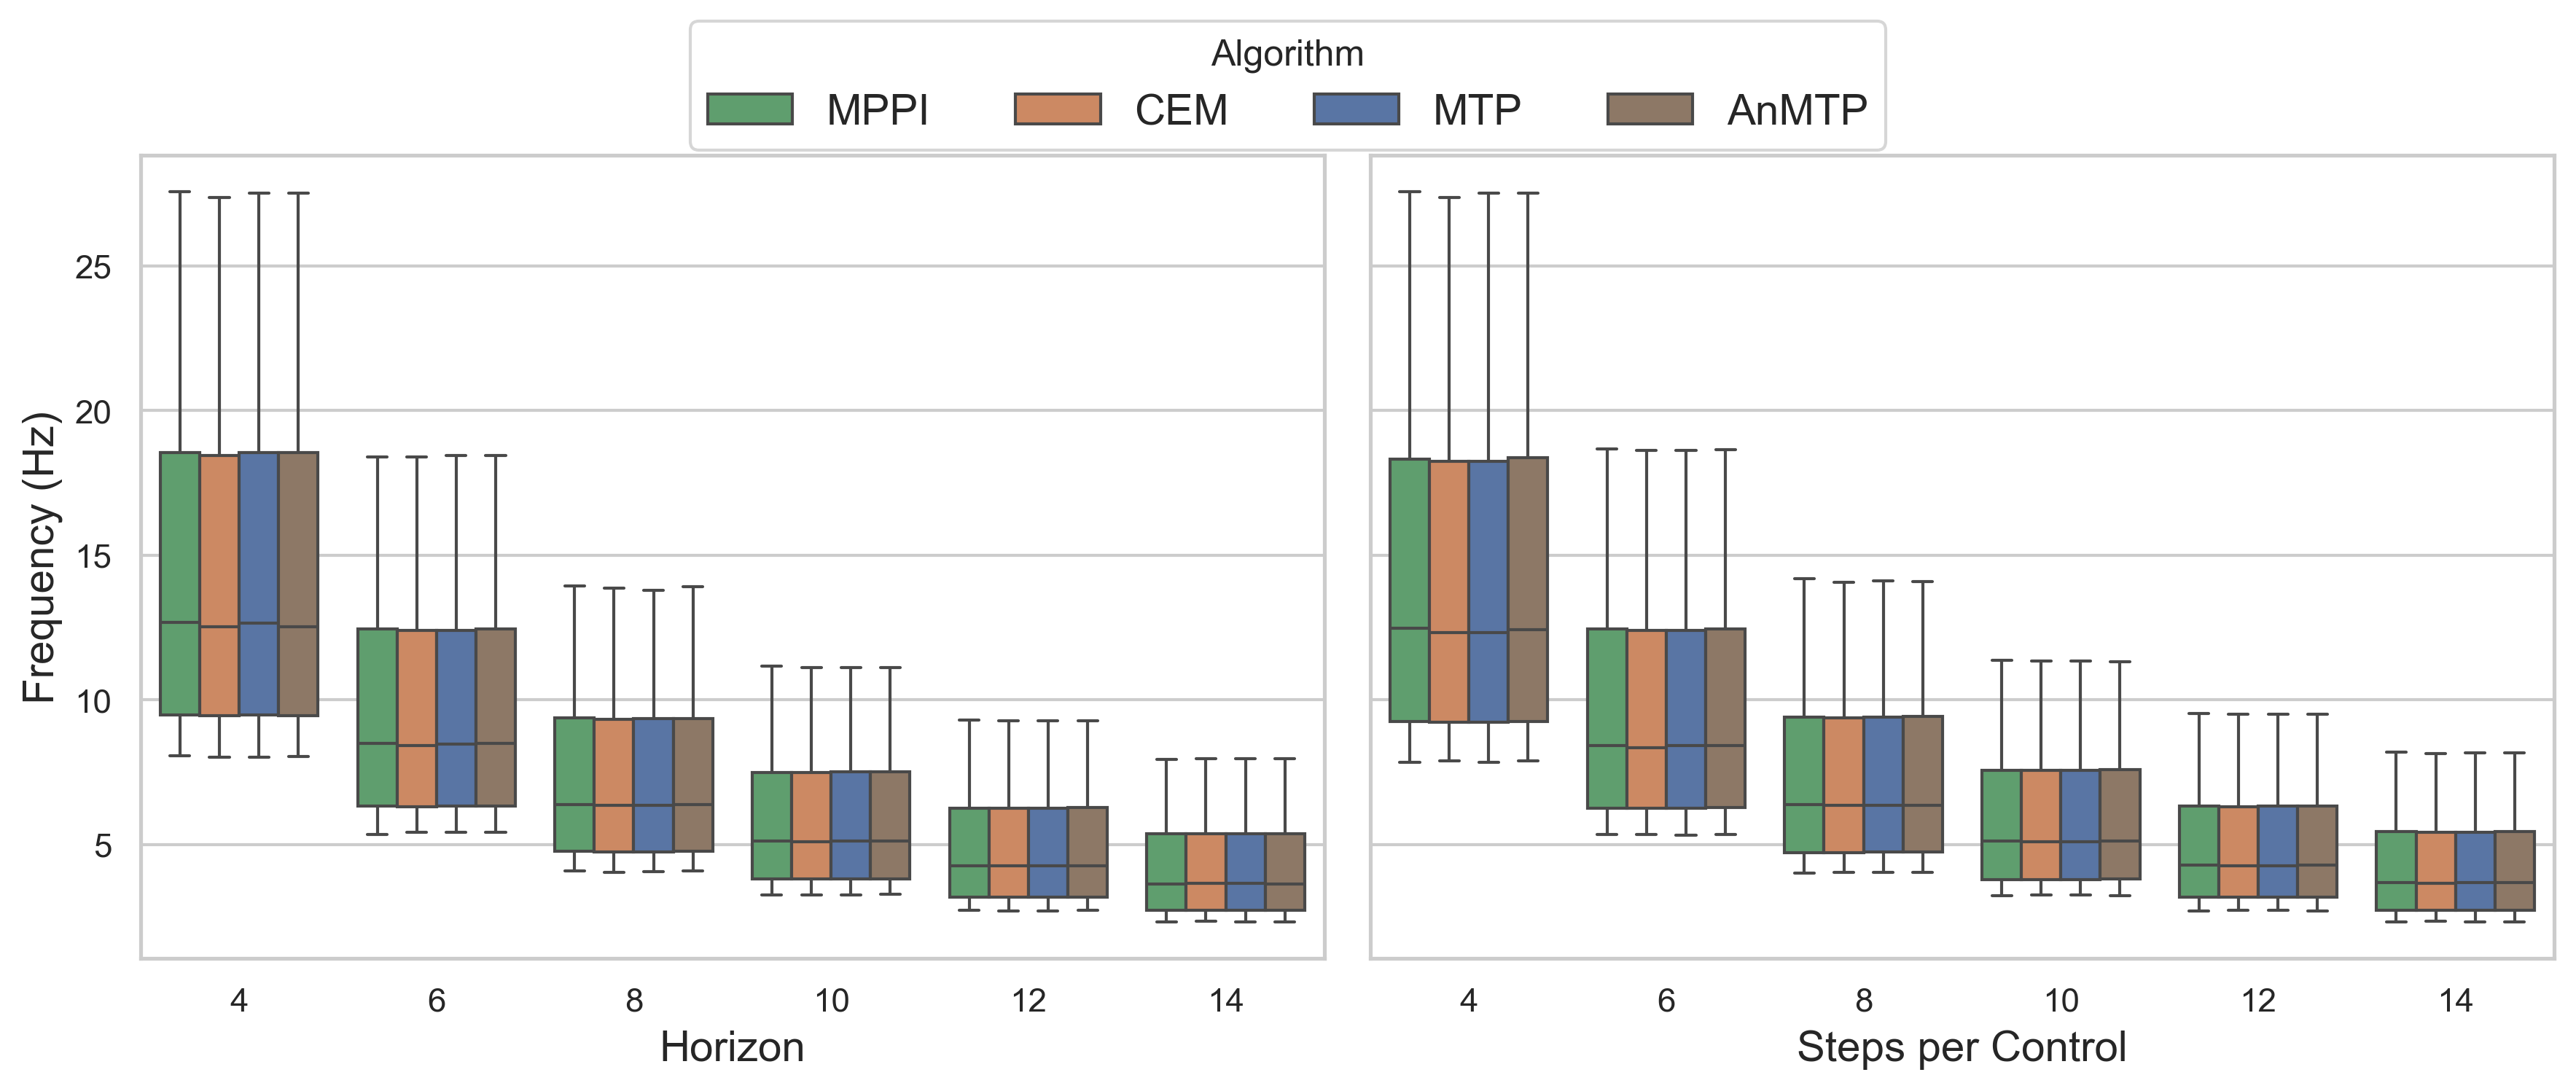

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: Runtime vs Horizon
sns.boxplot(data=df2, x='Horizon', y='Frequency', hue='Algorithm', palette=palette, ax=axes[0])
axes[0].set_xlabel('Horizon')
axes[0].set_ylabel('Frequency (Hz)')

# Right: Runtime vs Steps per Control
sns.boxplot(data=df2, x='Steps per Control', y='Frequency', hue='Algorithm', palette=palette, ax=axes[1])
axes[1].set_xlabel('Steps per Control')
axes[1].set_ylabel('Frequency (Hz)')

# Improve legend layout
axes[0].legend_.remove()  # Remove duplicate legend
axes[1].legend_.remove()  # Remove duplicate legend

plt.subplots_adjust(top=0.95)

# ---- Fix the legend duplication ----
# Get unique handles and labels from one of the subplots
handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))  # removes duplicates while preserving order

# Add a single legend for the whole figure
fig.legend(
    unique.values(),
    unique.keys(),
    title='Algorithm',
    loc='upper center',
    ncol=len(unique),  # one row of legend items
    bbox_to_anchor=(0.5, 1.02)
)
# fig.legend(title='Algorithm', loc='upper center', ncol=1, )

plt.tight_layout(rect=[0, 0, 1, 0.92])  # prevent overlap with legend
mkdir(f"{img_path}/scaling")
plt.savefig(f"{img_path}/scaling/horizon_sweep.pdf", bbox_inches="tight", dpi=300)

plt.show()